# 02 — Preprocessing: Preparing Extreme Events for DBSCAN
**Project:** GB Compound Hazards Risk Prioritization  
**Course:** Artificial Intelligence in Human Water Systems  

---
## Objectives
- Load pre-filtered extreme observations (p0005) from EDA output
- Convert spatiotemporal data into point format for DBSCAN
- Build a space-time cube representation (latitude, longitude, time)
- Normalize coordinates for DBSCAN distance calculation
- Save formatted point arrays ready for clustering


## 1. Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully!')

Libraries loaded successfully!


# 2. 99th percentile computation 

In [3]:
# ============================================================
# REVISED APPROACH: Compute own 99th percentile from p0005
# p0005 contains full grid values — we apply our own threshold
# This is consistent with Tilloy et al. (2022) methodology
# ============================================================

import xarray as xr
import numpy as np
import pandas as pd

rain_ds = xr.open_dataset('../data/raw/raindat_0919.nc')
wind_ds = xr.open_dataset('../data/raw/windat_0919.nc')

rain_p0005 = rain_ds['p0005'] * 1000  # Convert to mm
wind_p0005 = wind_ds['p0005']

# Compute 99th percentile threshold per grid cell across all timesteps
print('Computing 99th percentile thresholds...')
rain_threshold = rain_p0005.quantile(0.99, dim='time')
wind_threshold = wind_p0005.quantile(0.99, dim='time')

# Create extreme masks
rain_extreme_mask = rain_p0005 > rain_threshold
wind_extreme_mask = wind_p0005 > wind_threshold

print(f'Rain extreme observations: {int(rain_extreme_mask.sum().values):,}')
print(f'Wind extreme observations: {int(wind_extreme_mask.sum().values):,}')

Computing 99th percentile thresholds...
Rain extreme observations: 36,925
Wind extreme observations: 39,109


# 3. Extract extreme DataFrames

In [4]:
# Extract extreme points as DataFrames
rain_extreme_df = rain_p0005.where(rain_extreme_mask).to_dataframe(name='precipitation').dropna().reset_index()
wind_extreme_df = wind_p0005.where(wind_extreme_mask).to_dataframe(name='wind').dropna().reset_index()

print('Rain extreme points:')
print(rain_extreme_df.head())
print(f'Shape: {rain_extreme_df.shape}')

print('\nWind extreme points:')
print(wind_extreme_df.head())
print(f'Shape: {wind_extreme_df.shape}')

Rain extreme points:
                 time  latitude  longitude  quantile  precipitation
0 2019-09-01 14:00:00     57.00       -3.0      0.99       1.941611
1 2019-09-01 15:00:00     57.25       -3.0      0.99       2.320221
2 2019-09-01 16:00:00     58.25       -4.5      0.99       1.962654
3 2019-09-01 16:00:00     58.00       -4.5      0.99       1.984668
4 2019-09-01 16:00:00     57.75       -5.0      0.99       2.204000
Shape: (36925, 5)

Wind extreme points:
                 time  latitude  longitude  quantile       wind
0 2019-09-04 10:00:00     55.00      -3.75      0.99  17.111587
1 2019-09-04 10:00:00     55.00      -3.50      0.99  15.872145
2 2019-09-04 10:00:00     55.00      -3.25      0.99  15.193310
3 2019-09-04 10:00:00     53.75      -6.50      0.99  16.479377
4 2019-09-04 10:00:00     53.75      -6.25      0.99  17.295865
Shape: (39109, 5)


# 4. Build space-time points

In [5]:
# Drop quantile column and rename for consistency
rain_extreme_df = rain_extreme_df.drop(columns=['quantile'])
wind_extreme_df = wind_extreme_df.drop(columns=['quantile'])

# Build space-time points for DBSCAN
def build_spacetime_points(df, value_col, resolution=0.25):
    norm_lat = (df['latitude'].values - df['latitude'].min()) / resolution
    norm_lon = (df['longitude'].values - df['longitude'].min()) / resolution
    
    t0 = pd.to_datetime(df['time'].min())
    norm_time = (pd.to_datetime(df['time']) - t0).dt.total_seconds() / 3600
    
    points = np.column_stack([norm_lat, norm_lon, norm_time.values])
    values = df[value_col].values
    return points, values

rain_points, rain_values = build_spacetime_points(rain_extreme_df, 'precipitation')
wind_points, wind_values = build_spacetime_points(wind_extreme_df, 'wind')

print(f'Rain points shape: {rain_points.shape}')
print(f'Wind points shape: {wind_points.shape}')
print(f'\nRain ranges:')
print(f'  Lat:  {rain_points[:,0].min():.1f} to {rain_points[:,0].max():.1f} grid cells')
print(f'  Lon:  {rain_points[:,1].min():.1f} to {rain_points[:,1].max():.1f} grid cells')
print(f'  Time: {rain_points[:,2].min():.1f} to {rain_points[:,2].max():.1f} hours')
print(f'\nWind ranges:')
print(f'  Lat:  {wind_points[:,0].min():.1f} to {wind_points[:,0].max():.1f} grid cells')
print(f'  Lon:  {wind_points[:,1].min():.1f} to {wind_points[:,1].max():.1f} grid cells')
print(f'  Time: {wind_points[:,2].min():.1f} to {wind_points[:,2].max():.1f} hours')

Rain points shape: (36925, 3)
Wind points shape: (39109, 3)

Rain ranges:
  Lat:  0.0 to 52.0 grid cells
  Lon:  0.0 to 40.0 grid cells
  Time: 0.0 to 1600.0 hours

Wind ranges:
  Lat:  0.0 to 52.0 grid cells
  Lon:  0.0 to 40.0 grid cells
  Time: 0.0 to 1652.0 hours


## 5. k-NN Distance Plot — Choosing ε for DBSCAN

We use the k-NN distance plot to identify the optimal ε parameter for DBSCAN. The "knee" in the plot separates core cluster points (low k-NN distance) from noise points (high k-NN distance), following Tilloy et al. (2022).

Computing k-NN distances for precipitation (k=10)...


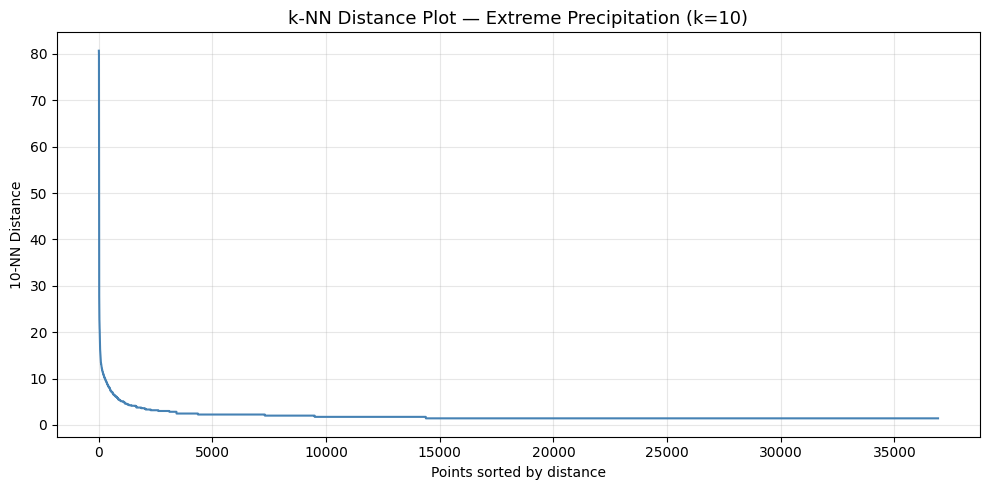


Computing k-NN distances for wind (k=10)...


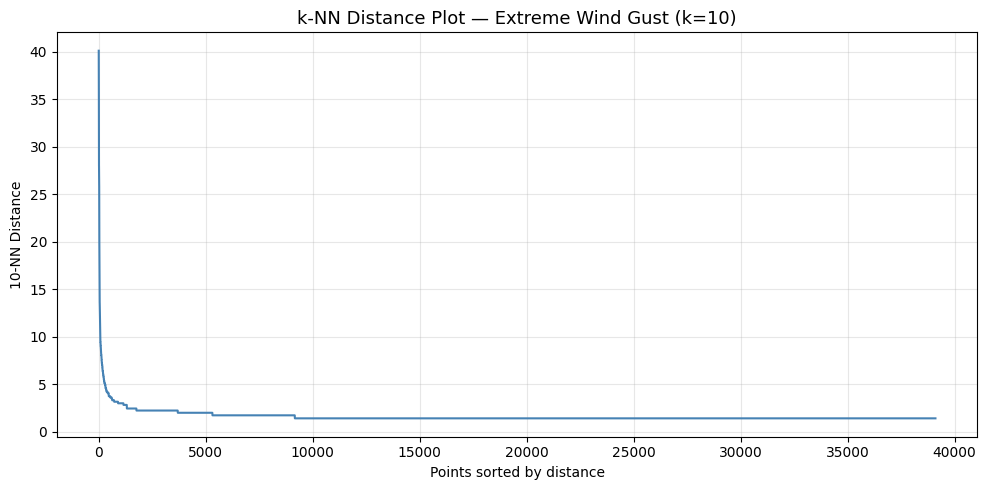

In [6]:
from sklearn.neighbors import NearestNeighbors

def plot_knn_distances(points, k=10, sample_size=50000, title='k-NN Distance Plot'):
    """
    Plot sorted k-NN distances to identify optimal epsilon for DBSCAN.
    Uses a random sample for computational efficiency.
    """
    # Sample for efficiency on large datasets
    if len(points) > sample_size:
        idx = np.random.choice(len(points), sample_size, replace=False)
        sample = points[idx]
        print(f'  Using random sample of {sample_size:,} points out of {len(points):,}')
    else:
        sample = points
    
    nbrs = NearestNeighbors(n_neighbors=k).fit(sample)
    distances, _ = nbrs.kneighbors(sample)
    distances = np.sort(distances[:, k-1])[::-1]
    
    plt.figure(figsize=(10, 5))
    plt.plot(distances, color='steelblue')
    plt.title(title, fontsize=13)
    plt.xlabel('Points sorted by distance')
    plt.ylabel(f'{k}-NN Distance')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    return distances

print('Computing k-NN distances for precipitation (k=10)...')
rain_distances = plot_knn_distances(
    rain_points, k=10,
    title='k-NN Distance Plot — Extreme Precipitation (k=10)'
)
plt.savefig('../outputs/figures/02_knn_distances_rain.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nComputing k-NN distances for wind (k=10)...')
wind_distances = plot_knn_distances(
    wind_points, k=10,
    title='k-NN Distance Plot — Extreme Wind Gust (k=10)'
)
plt.savefig('../outputs/figures/02_knn_distances_wind.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Define DBSCAN Parameters

> **Instructions:** Look at the k-NN distance plots above and identify the "knee" — the point where the curve starts to rise steeply. The distance value at the knee is your ε. Update the values below accordingly.

Based on the k-NN distance plots above, the knee is identified 
around distance 2.0 for both variables. We select:
- ε_rain = 2.0
- ε_wind = 2.0
- min_samples = 10

Note: These values differ from Tilloy et al. (2022) (ε≈2.45, ε≈2.24) 
because our coordinate system uses 1 unit = 1 grid cell (0.25°) = 1 hour,
applied to a filtered sparse dataset of truly extreme observations
computed via our own 99th percentile threshold.

In [13]:
# ============================================================
# DBSCAN PARAMETERS — adjust based on k-NN plots above
# ============================================================
PARAMS = {
    'rain': {
        'eps': 2.0,
        'min_samples': 10
    },
    'wind': {
        'eps': 2.0,
        'min_samples': 10
    }
}

## 7. Save Preprocessed Point Arrays

In [14]:
import json

# Save point arrays
np.save('../data/processed/rain_points.npy', rain_points)
np.save('../data/processed/rain_values.npy', rain_values)
np.save('../data/processed/wind_points.npy', wind_points)
np.save('../data/processed/wind_values.npy', wind_values)

# Save DBSCAN parameters
with open('../data/processed/dbscan_params.json', 'w') as f:
    json.dump(PARAMS, f, indent=2)

# Save reference time
t0_rain = str(rain_extreme_df['time'].min())
t0_wind = str(wind_extreme_df['time'].min())
with open('../data/processed/time_references.json', 'w') as f:
    json.dump({'rain': t0_rain, 'wind': t0_wind}, f, indent=2)

print('Saved:')
print('  data/processed/rain_points.npy')
print('  data/processed/rain_values.npy')
print('  data/processed/wind_points.npy')
print('  data/processed/wind_values.npy')
print('  data/processed/dbscan_params.json')
print('  data/processed/time_references.json')

Saved:
  data/processed/rain_points.npy
  data/processed/rain_values.npy
  data/processed/wind_points.npy
  data/processed/wind_values.npy
  data/processed/dbscan_params.json
  data/processed/time_references.json
